##Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

##Load CIFAR-10

In [2]:
def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    X = batch[b"data"]
    y = batch[b"labels"]

    return X, np.array(y)

In [4]:
X1, y1 = load_batch("data_batch_1")
X2, y2 = load_batch("data_batch_2")
X3, y3 = load_batch("data_batch_3")
X4, y4 = load_batch("data_batch_4")
X5, y5 = load_batch("data_batch_5")

##Flatten and normalize images

In [6]:
X_train = np.concatenate([X1, X2, X3, X4, X5], axis=0)
y_train = np.concatenate([y1, y2, y3, y4, y5], axis=0)

X_test, y_test = load_batch("test_batch")

# Convert labels from shape (n, 1) to (n,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Original training data:", X_train.shape)
print("Original testing data :", X_test.shape)

Original training data: (50000, 3072)
Original testing data : (10000, 3072)


In [7]:
# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (50000, 3072)
Testing shape : (10000, 3072)


##Select subset for experimentation

In [8]:
# Use a subset initially
TRAIN_SIZE = 5000
TEST_SIZE = 1000

X_train_small = X_train[:TRAIN_SIZE]
y_train_small = y_train[:TRAIN_SIZE]

X_test_small = X_test[:TEST_SIZE]
y_test_small = y_test[:TEST_SIZE]

print("Training subset:", X_train_small.shape)
print("Testing subset :", X_test_small.shape)

Training subset: (5000, 3072)
Testing subset : (1000, 3072)


##Defining and storing distance functions

In [9]:
def euclidean_distance(X1, X2):
    return np.sqrt(np.sum((X1 - X2) ** 2, axis=1))

def manhattan_distance(X1, X2):
    return np.sum(np.abs(X1 - X2), axis=1)

def minkowski_distance(X1, X2, p=3):
    return np.sum(np.abs(X1 - X2) ** p, axis=1) ** (1 / p)

def cosine_distance(X1, X2):
    denominator = np.linalg.norm(X1) * np.linalg.norm(X2)
    if denominator == 0:
        return 1.0
    similarity = np.dot(X1, X2) / denominator
    similarity = np.clip(similarity, -1.0, 1.0)
    return 1.0 - similarity

def hamming_distance(X1, X2):
    return np.mean(X1 != X2, axis=1)


distance_functions = {
    "Euclidean": euclidean_distance,
    "Manhattan": manhattan_distance,
    "Minkowski": minkowski_distance,
    "Cosine": cosine_distance,
    "Hamming": hamming_distance
}

##KNN prediction

In [10]:
def knn_predict(X_train, y_train, X_test, k, distance_function):

    predictions = []

    for test_sample in X_test:

        distances = distance_function(X_train, test_sample)

        # Get indices of K nearest neighbors
        nearest_indices = np.argsort(distances)[:k]

        # Get their labels
        nearest_labels = y_train[nearest_indices]

        # Majority voting
        counts = np.bincount(nearest_labels, minlength=10)

        prediction = np.argmax(counts)

        predictions.append(prediction)

    return np.array(predictions)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

##Run experiments on different K values

In [12]:
k_values = [3, 4, 9, 20, 47]

results = []

for distance_name, distance_function in distance_functions.items():

    for k in k_values:

        print(f"Running {distance_name}, K = {k}")

        predictions = knn_predict(
            X_train_small,
            y_train_small,
            X_test_small,
            k,
            distance_function
        )

        acc = accuracy(y_test_small, predictions)

        results.append({
            "Distance": distance_name,
            "K": k,
            "Accuracy": acc
        })

Running Euclidean, K = 3
Running Euclidean, K = 4
Running Euclidean, K = 9
Running Euclidean, K = 20
Running Euclidean, K = 47
Running Manhattan, K = 3
Running Manhattan, K = 4
Running Manhattan, K = 9
Running Manhattan, K = 20
Running Manhattan, K = 47
Running Minkowski, K = 3
Running Minkowski, K = 4
Running Minkowski, K = 9
Running Minkowski, K = 20
Running Minkowski, K = 47
Running Cosine, K = 3
Running Cosine, K = 4
Running Cosine, K = 9
Running Cosine, K = 20
Running Cosine, K = 47
Running Hamming, K = 3
Running Hamming, K = 4
Running Hamming, K = 9
Running Hamming, K = 20
Running Hamming, K = 47


##Results table

In [14]:
results_df = pd.DataFrame(results)

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

results_df

,Distance,K,Accuracy,Accuracy (%)
0,Euclidean,3,0.261,26.1
1,Euclidean,4,0.268,26.8
2,Euclidean,9,0.270,27.0
3,Euclidean,20,0.269,26.9
4,Euclidean,47,0.251,25.1
5,Manhattan,3,0.278,27.8
6,Manhattan,4,0.293,29.3
7,Manhattan,9,0.301,30.1
8,Manhattan,20,0.295,29.5
9,Manhattan,47,0.292,29.2


##Accuracy table

In [15]:
accuracy_table = results_df.pivot(
    index="Distance",
    columns="K",
    values="Accuracy (%)"
)

print(accuracy_table.round(2))

K            3     4     9     20    47
Distance                               
Cosine     10.4  10.3  11.1  10.4  10.4
Euclidean  26.1  26.8  27.0  26.9  25.1
Hamming    20.6  23.9  23.9  26.1  26.7
Manhattan  27.8  29.3  30.1  29.5  29.2
Minkowski  21.7  22.7  25.5  24.7  22.1


##Finding the best model

In [16]:
best_result = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Distance :", best_result["Distance"])
print("Best K        :", best_result["K"])
print("Best Accuracy :", f"{best_result['Accuracy'] * 100:.2f}%")

Best Distance : Manhattan
Best K        : 9
Best Accuracy : 30.10%


##Accuracy graph

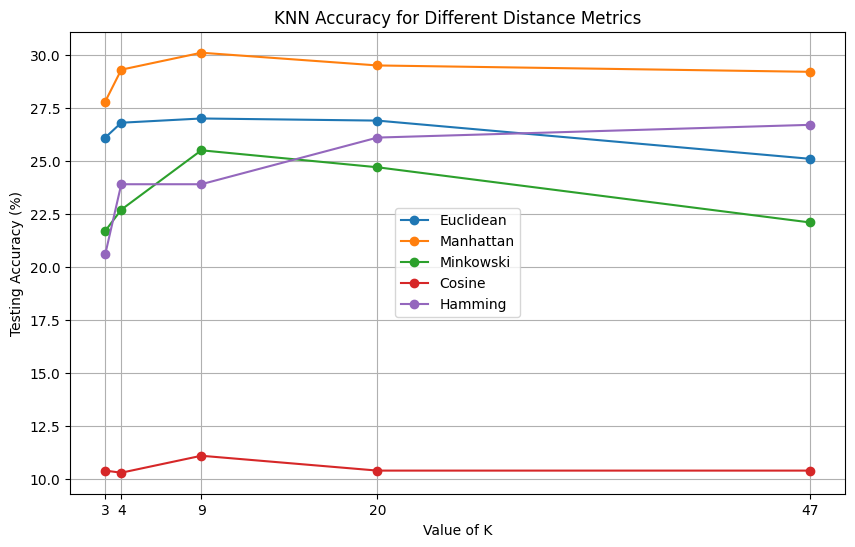

In [17]:
plt.figure(figsize=(10, 6))

for distance_name in distance_functions.keys():

    data = results_df[
        results_df["Distance"] == distance_name
    ]

    plt.plot(
        data["K"],
        data["Accuracy (%)"],
        marker="o",
        label=distance_name
    )

plt.xlabel("Value of K")
plt.ylabel("Testing Accuracy (%)")
plt.title("KNN Accuracy for Different Distance Metrics")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

##Confusion matrix function

In [18]:
def confusion_matrix_from_scratch(y_true, y_pred, num_classes=10):

    cm = np.zeros((num_classes, num_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        cm[actual][predicted] += 1

    return cm

##Generate confusion matrix

In [28]:
cm = confusion_matrix_from_scratch(
    y_test_small,
    best_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[52  0 12  0  8  0  5  1 24  1]
 [ 9 12 14  5 16  1  9  0 19  4]
 [18  0 49  4 19  2  3  1  4  0]
 [ 9  2 25 15 23  8 17  1  3  0]
 [ 9  2 29  3 32  2  5  1  6  1]
 [ 8  1 24  7 24 10  8  2  2  0]
 [ 3  2 39  5 36  2 21  2  2  0]
 [ 6  0 28  5 24  2  9 18  8  2]
 [18  1  5  1  8  2  1  0 68  2]
 [15  1 14  5 10  2 10  4 24 24]]


##Plot confusion matrix with values

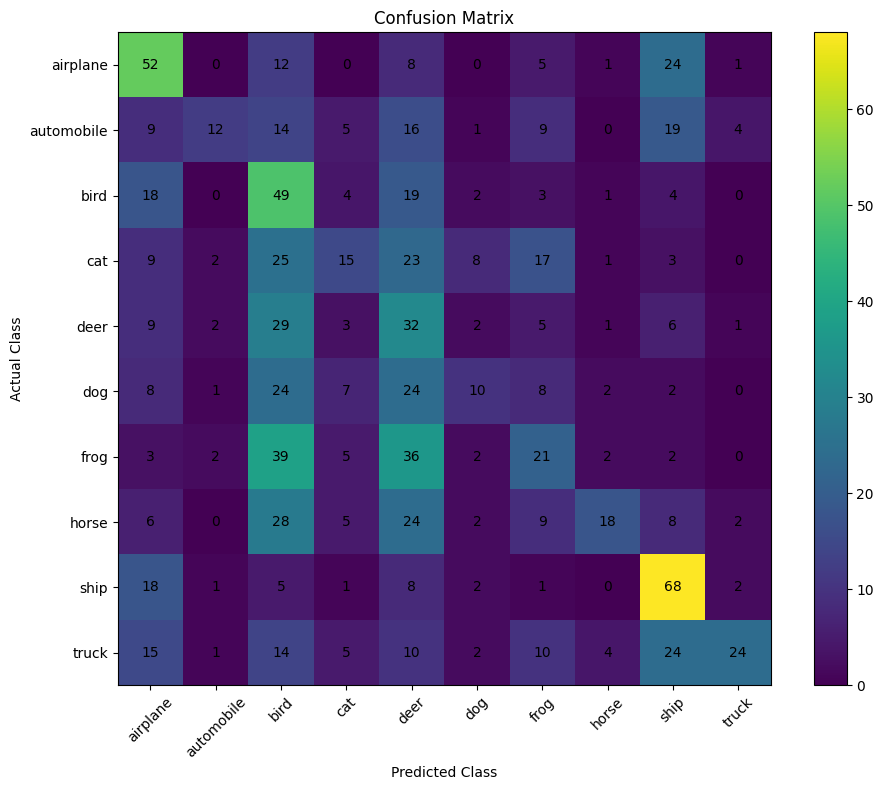

In [26]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

# Add values inside each cell
for i in range(10):
    for j in range(10):
        plt.text(j,i,cm[i, j],ha="center",va="center")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

##Precision and recall

In [23]:
def precision_recall(cm):

    num_classes = cm.shape[0]

    precision = []
    recall = []

    for i in range(num_classes):

        TP = cm[i, i]

        FP = np.sum(cm[:, i]) - TP

        FN = np.sum(cm[i, :]) - TP

        p = TP / (TP + FP) if (TP + FP) != 0 else 0

        r = TP / (TP + FN) if (TP + FN) != 0 else 0

        precision.append(p)
        recall.append(r)

    return np.array(precision), np.array(recall)

precision, recall = precision_recall(cm)


##Display precision and recall

In [24]:
metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall
})

metrics_df["Precision"] *= 100
metrics_df["Recall"] *= 100

print(metrics_df.round(2))

        Class  Precision  Recall
0    airplane      35.37   50.49
1  automobile      57.14   13.48
2        bird      20.50   49.00
3         cat      30.00   14.56
4        deer      16.00   35.56
5         dog      32.26   11.63
6        frog      23.86   18.75
7       horse      60.00   17.65
8        ship      42.50   64.15
9       truck      70.59   22.02


##Final summary

In [29]:
print("\n========== FINAL RESULT ==========")

print("Best Distance :", best_distance_name)
print("Best K        :", best_k)
print("Best Accuracy :", f"{best_result['Accuracy'] * 100:.2f}%")

print("\n========== PRECISION & RECALL ==========")

print(metrics_df.round(2))

print("\n========== CONFUSION MATRIX ==========")

print(cm)


========== FINAL RESULT ==========
Best Distance : Manhattan
Best K        : 9
Best Accuracy : 30.10%

========== PRECISION & RECALL ==========
        Class  Precision  Recall
0    airplane      35.37   50.49
1  automobile      57.14   13.48
2        bird      20.50   49.00
3         cat      30.00   14.56
4        deer      16.00   35.56
5         dog      32.26   11.63
6        frog      23.86   18.75
7       horse      60.00   17.65
8        ship      42.50   64.15
9       truck      70.59   22.02

========== CONFUSION MATRIX ==========
[[52  0 12  0  8  0  5  1 24  1]
 [ 9 12 14  5 16  1  9  0 19  4]
 [18  0 49  4 19  2  3  1  4  0]
 [ 9  2 25 15 23  8 17  1  3  0]
 [ 9  2 29  3 32  2  5  1  6  1]
 [ 8  1 24  7 24 10  8  2  2  0]
 [ 3  2 39  5 36  2 21  2  2  0]
 [ 6  0 28  5 24  2  9 18  8  2]
 [18  1  5  1  8  2  1  0 68  2]
 [15  1 14  5 10  2 10  4 24 24]]
